# **Customer Churn Analysis and Prediction Using Data Analytics and Machine Learning**

## Integrated Data Analytics and Machine Learning Project

### Project Overview

This project focuses on analyzing customer data to identify patterns and factors associated with customer churn. The project combines Exploratory Data Analysis (EDA), statistical analysis, data visualization, feature engineering, and machine learning techniques.

The analytical phase is used to understand customer behavior, service usage, billing patterns, satisfaction levels, support interactions, and other factors related to churn.

In the machine learning phase, classification models are developed to predict whether a customer is likely to churn based on the available customer attributes.

### Dataset

The dataset contains customer-level information including demographic details, services, contract and billing information, usage behavior, support interactions, satisfaction scores, and churn status.

### Main Objective

To perform comprehensive customer churn analytics and develop machine learning models capable of predicting customer churn.

# 1. Import Required Libraries

In this section, the required Python libraries are imported for data manipulation, statistical analysis, visualization, preprocessing, machine learning, and model evaluation.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Data Preparation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 2. Load Dataset

The customer churn dataset is stored in an Excel file. The dataset is loaded into a Pandas DataFrame for further analysis and machine learning.

The Excel workbook contains a sheet named `raw_data`.

In [ ]:
# Upload the Excel file to Google Colab before running this cell

from google.colab import files

uploaded = files.upload()

Saving Customer_Churn_Prediction_Codec.xlsx to Customer_Churn_Prediction_Codec.xlsx


In [ ]:
# Load the uploaded Excel dataset

file_name = "Customer_Churn_Prediction_Codec.xlsx"

df = pd.read_excel(
    file_name,
    sheet_name="raw_data"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 3. Initial Dataset Overview

This section provides an initial understanding of the dataset, including the number of records, number of variables, column names, data types, and sample observations.

In [ ]:
# Display the first five records

df.head()

,CustomerID,Gender,Age,SeniorCitizen,MaritalStatus,Dependents,Education,EmploymentStatus,Income,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlyUsageGB,NumSupportTickets,LatePayments,SatisfactionScore,CityTier,Referral,Churn
0,CUST0000001,Female,25,No,Married,No,High School,Employed,179009,41,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,No,Two year,Yes,Mailed check,80.30,3272.42,588.1,1,1,5,Tier-2,No,No
1,CUST0000002,Male,65,Yes,Married,Yes,Post Graduate,Student,113300,66,Yes,No,DSL,Yes,No,No,Yes,No,No,Month-to-month,No,Bank transfer,96.53,6398.54,342.8,1,4,3,Tier-2,Yes,No
2,CUST0000003,Female,54,No,Married,Yes,Graduate,Self-Employed,49985,29,Yes,No,Cable,No,No,No,No,No,No,Month-to-month,No,Credit card,111.90,3228.65,168.7,8,5,1,Tier-1,Yes,Yes
3,CUST0000004,Female,59,No,Married,Yes,Graduate,Student,137971,59,Yes,Yes,DSL,No,No,Yes,No,No,Yes,Month-to-month,No,Mailed check,116.43,6858.98,124.8,5,1,4,Tier-2,Yes,No
4,CUST0000005,Male,46,No,Single,Yes,Post Graduate,Employed,161248,2,Yes,No,Cable,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Mailed check,31.06,69.15,575.4,8,6,4,Tier-3,No,Yes


In [ ]:
# Display the last five records

df.tail()

,CustomerID,Gender,Age,SeniorCitizen,MaritalStatus,Dependents,Education,EmploymentStatus,Income,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlyUsageGB,NumSupportTickets,LatePayments,SatisfactionScore,CityTier,Referral,Churn
19995,CUST0019996,Female,57,No,Single,No,High School,Employed,137379,20,Yes,Yes,Cable,No,No,Yes,Yes,Yes,No,Month-to-month,No,Electronic check,124.49,2461.59,171.0,2,6,3,Tier-3,Yes,No
19996,CUST0019997,Female,32,No,Single,Yes,Post Graduate,Employed,88133,8,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer,53.33,427.98,391.6,1,6,1,Tier-3,Yes,Yes
19997,CUST0019998,Female,69,Yes,Single,No,Graduate,Employed,136008,25,Yes,No,Fiber optic,No,No,Yes,No,No,Yes,Two year,No,Mailed check,131.36,3303.73,320.4,0,2,4,Tier-3,Yes,No
19998,CUST0019999,Female,59,No,Married,Yes,Post Graduate,Self-Employed,88762,57,Yes,Yes,Cable,Yes,No,Yes,Yes,Yes,No,Month-to-month,No,Bank transfer,64.26,3669.99,257.2,2,0,2,Tier-3,Yes,No
19999,CUST0020000,Male,33,No,Married,Yes,Graduate,Employed,89988,5,Yes,Yes,DSL,No,No,No,No,Yes,Yes,One year,No,Bank transfer,118.58,560.76,129.1,5,3,3,Tier-2,Yes,Yes


In [ ]:
# Display number of rows and columns

rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 20000
Number of Columns: 31


In [ ]:
# Display all column names

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. CustomerID
2. Gender
3. Age
4. SeniorCitizen
5. MaritalStatus
6. Dependents
7. Education
8. EmploymentStatus
9. Income
10. TenureMonths
11. PhoneService
12. MultipleLines
13. InternetService
14. OnlineSecurity
15. OnlineBackup
16. DeviceProtection
17. TechSupport
18. StreamingTV
19. StreamingMovies
20. Contract
21. PaperlessBilling
22. PaymentMethod
23. MonthlyCharges
24. TotalCharges
25. AvgMonthlyUsageGB
26. NumSupportTickets
27. LatePayments
28. SatisfactionScore
29. CityTier
30. Referral
31. Churn


In [ ]:
# Display data types of all columns

df.dtypes

,0
CustomerID,object
Gender,object
Age,int64
SeniorCitizen,object
MaritalStatus,object
Dependents,object
Education,object
EmploymentStatus,object
Income,int64
TenureMonths,int64


In [ ]:
# Display detailed dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         20000 non-null  object 
 1   Gender             20000 non-null  object 
 2   Age                20000 non-null  int64  
 3   SeniorCitizen      20000 non-null  object 
 4   MaritalStatus      20000 non-null  object 
 5   Dependents         20000 non-null  object 
 6   Education          20000 non-null  object 
 7   EmploymentStatus   20000 non-null  object 
 8   Income             20000 non-null  int64  
 9   TenureMonths       20000 non-null  int64  
 10  PhoneService       20000 non-null  object 
 11  MultipleLines      20000 non-null  object 
 12  InternetService    20000 non-null  object 
 13  OnlineSecurity     20000 non-null  object 
 14  OnlineBackup       20000 non-null  object 
 15  DeviceProtection   20000 non-null  object 
 16  TechSupport        200

# 4. Statistical Summary

Descriptive statistics are used to understand the central tendency, dispersion, and distribution of numerical variables in the dataset.

In [ ]:
# Statistical summary of numerical variables

df.describe()

,Age,Income,TenureMonths,MonthlyCharges,TotalCharges,AvgMonthlyUsageGB,NumSupportTickets,LatePayments,SatisfactionScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,46.552550,98652.507800,36.354050,79.913252,2909.377386,302.687035,3.994350,2.989050,2.999550
std,16.772394,46833.313482,20.832371,34.635237,2211.465410,170.843739,2.576635,2.014506,1.415927
min,18.000000,18002.000000,1.000000,20.000000,-11.100000,10.100000,0.000000,0.000000,1.000000
25%,32.000000,57845.500000,18.000000,49.980000,1128.975000,153.400000,2.000000,1.000000,2.000000
50%,47.000000,98005.500000,36.000000,79.865000,2352.305000,300.500000,4.000000,3.000000,3.000000
75%,61.000000,139579.500000,54.000000,110.165000,4292.185000,450.900000,6.000000,5.000000,4.000000
max,75.000000,179978.000000,72.000000,140.000000,10059.350000,599.900000,8.000000,6.000000,5.000000


In [ ]:
# Statistical summary including categorical variables

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,20000,20000,CUST0019984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,20000,2,Male,10006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,46.55255,16.772394,18.0,32.0,47.0,61.0,75.0
SeniorCitizen,20000,2,No,14460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,20000,2,Married,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,20000,2,No,10109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,20000,3,Graduate,6718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmploymentStatus,20000,4,Employed,5050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,20000.0,NaN,NaN,NaN,98652.5078,46833.313482,18002.0,57845.5,98005.5,139579.5,179978.0
TenureMonths,20000.0,NaN,NaN,NaN,36.35405,20.832371,1.0,18.0,36.0,54.0,72.0


### 4.1 Total Charges Anomaly Check

The statistical summary indicates that the `TotalCharges` variable contains a negative minimum value. Since total charges would normally be expected to be non-negative, the negative value is treated as a potential data-quality anomaly.

The following analysis identifies the records containing negative `TotalCharges` values so that the issue can be documented before further analysis and machine learning.

## 5. Data Quality Analysis

Data quality analysis is performed to identify missing values and duplicate records in the dataset. These checks help ensure that the dataset is suitable for further exploratory analysis and machine learning.

In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values by Column:")
display(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check duplicate records
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Records:", duplicate_count)

# Check duplicate Customer IDs
duplicate_customer_ids = df["CustomerID"].duplicated().sum()

print("Duplicate Customer IDs:", duplicate_customer_ids)

Missing Values by Column:


,0



Total Missing Values: 0

Number of Duplicate Records: 0
Duplicate Customer IDs: 0


# 6. Categorical Variable Analysis

Categorical variables are analyzed to understand the distribution of customers across different demographic, service, contract, and payment categories.

In [ ]:
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Columns:")
for column in categorical_columns:
    print("-", column)

Categorical Columns:
- CustomerID
- Gender
- SeniorCitizen
- MaritalStatus
- Dependents
- Education
- EmploymentStatus
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- CityTier
- Referral
- Churn


In [ ]:
# Display value counts for selected important categorical variables

categorical_analysis_columns = [
    "Gender",
    "SeniorCitizen",
    "MaritalStatus",
    "Dependents",
    "Education",
    "EmploymentStatus",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "CityTier",
    "Churn"
]

for column in categorical_analysis_columns:
    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)
    print(df[column].value_counts())


Gender
Gender
Male      10006
Female     9994
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
No     14460
Yes     5540
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married    10000
Single     10000
Name: count, dtype: int64

Dependents
Dependents
No     10109
Yes     9891
Name: count, dtype: int64

Education
Education
Graduate         6718
High School      6646
Post Graduate    6636
Name: count, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         5050
Retired          5022
Self-Employed    5008
Student          4920
Name: count, dtype: int64

Contract
Contract
Month-to-month    10969
One year           5042
Two year           3989
Name: count, dtype: int64

InternetService
InternetService
DSL            6708
Fiber optic    6650
Cable          6642
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Credit card         5023
Mailed check        5004
Bank transfer       4995
Electronic check    4978
Name: count, dtype: int64

CityTier
CityTier
Tier-3    

# 7. Numerical Variable Analysis

Numerical variables are examined using descriptive statistics to understand customer age, income, tenure, charges, usage, support activity, late payments, and satisfaction.

In [ ]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Columns:")
for column in numerical_columns:
    print("-", column)

Numerical Columns:
- Age
- Income
- TenureMonths
- MonthlyCharges
- TotalCharges
- AvgMonthlyUsageGB
- NumSupportTickets
- LatePayments
- SatisfactionScore


In [ ]:
# Display numerical summary

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,46.552550,16.772394,18.0,32.000,47.000,61.000,75.00
Income,20000.0,98652.507800,46833.313482,18002.0,57845.500,98005.500,139579.500,179978.00
TenureMonths,20000.0,36.354050,20.832371,1.0,18.000,36.000,54.000,72.00
MonthlyCharges,20000.0,79.913252,34.635237,20.0,49.980,79.865,110.165,140.00
TotalCharges,20000.0,2909.377386,2211.465410,-11.1,1128.975,2352.305,4292.185,10059.35
AvgMonthlyUsageGB,20000.0,302.687035,170.843739,10.1,153.400,300.500,450.900,599.90
NumSupportTickets,20000.0,3.994350,2.576635,0.0,2.000,4.000,6.000,8.00
LatePayments,20000.0,2.989050,2.014506,0.0,1.000,3.000,5.000,6.00
SatisfactionScore,20000.0,2.999550,1.415927,1.0,2.000,3.000,4.000,5.00


# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify patterns, distributions, relationships, and trends in customer data.

The analysis begins with the distribution of the target variable, Churn, followed by demographic, service, billing, usage, and customer-support analysis.

## 8.1 Churn Distribution Analysis

The distribution of customers according to their churn status is analyzed to understand the proportion of customers who have churned and those who have remained with the company.

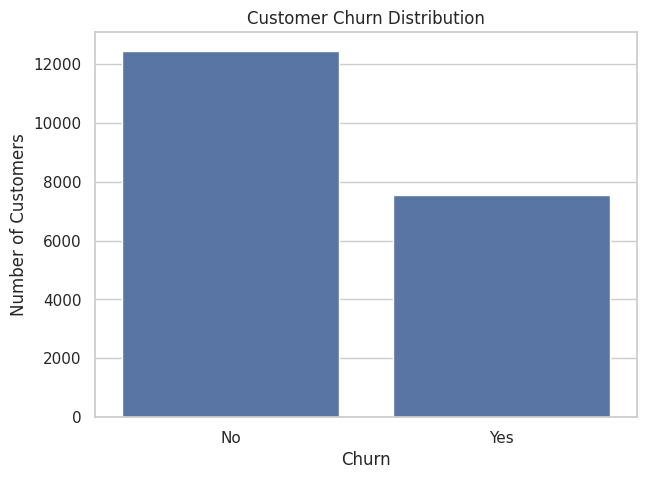

Churn Distribution:
Churn
No     12449
Yes     7551
Name: count, dtype: int64

Churn Percentage:
Churn
No     62.24
Yes    37.76
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

## 8.2 Age Analysis

The age distribution of customers is analyzed to understand the demographic characteristics of the customer base and its relationship with churn.

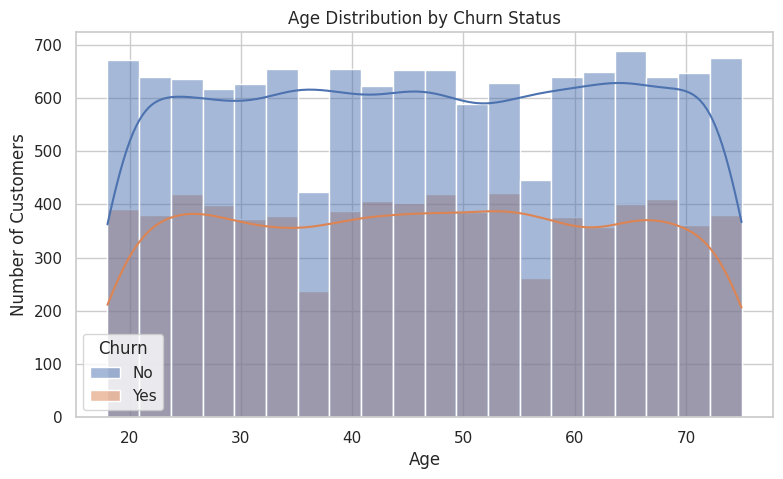

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Churn",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## 8.3 Gender Analysis

Customer churn is analyzed across different gender categories to identify differences in churn distribution.

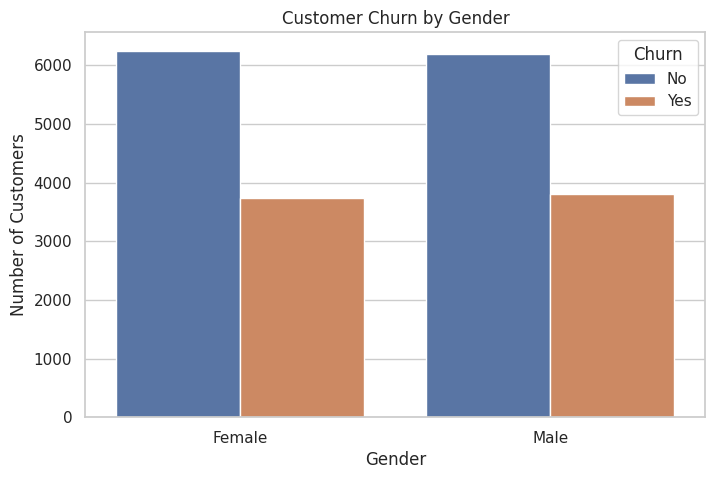

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 8.4 Contract Type and Churn Analysis

The relationship between contract type and customer churn is analyzed to determine how churn varies across different contract categories.

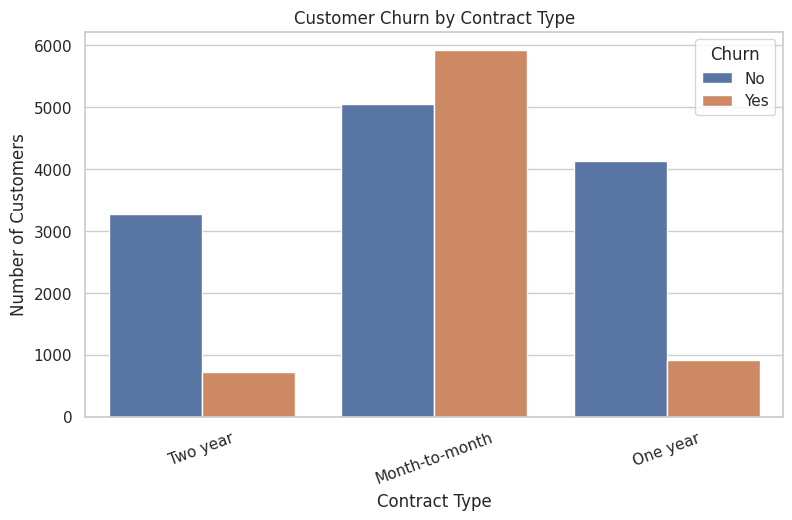

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

## 8.5 Monthly Charges Analysis

Monthly charges are analyzed to understand the billing distribution of customers and its relationship with customer churn.

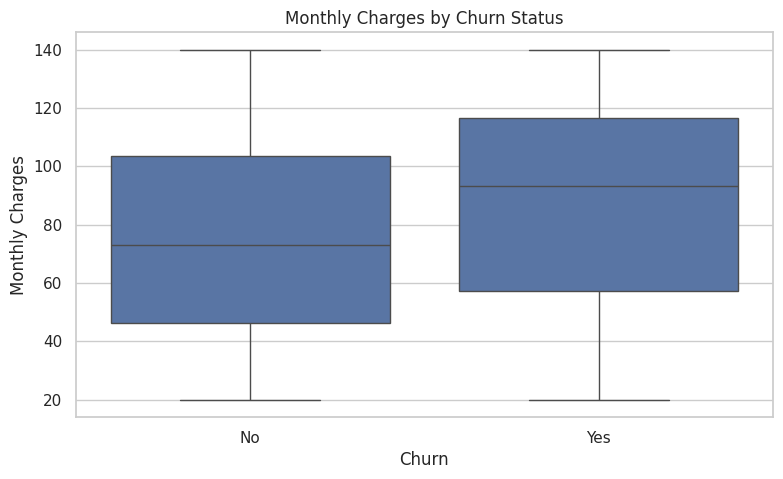

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## 8.6 Tenure Analysis

Customer tenure is analyzed to understand whether the length of the customer relationship differs between churned and retained customers.

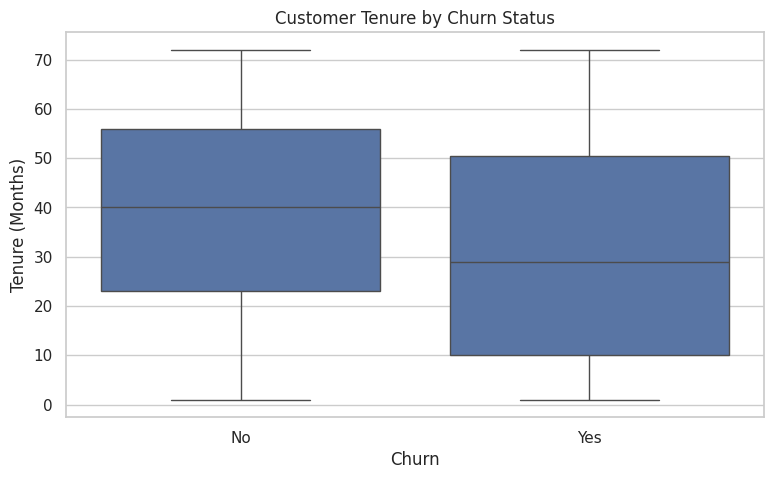

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TenureMonths"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## 8.7 Satisfaction Score Analysis

Customer satisfaction scores are analyzed to examine their relationship with customer churn.

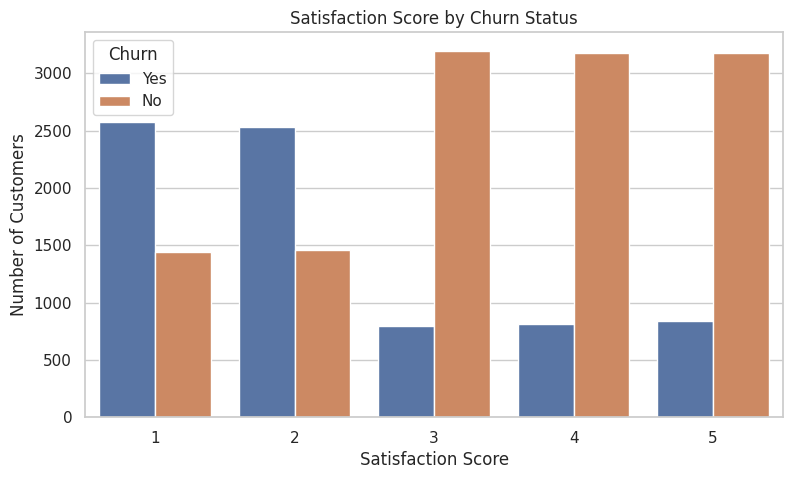

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="SatisfactionScore",
    hue="Churn"
)

plt.title("Satisfaction Score by Churn Status")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.show()

## 8.8 Support Ticket Analysis

The number of customer support tickets is analyzed to examine whether support activity differs between churned and retained customers.

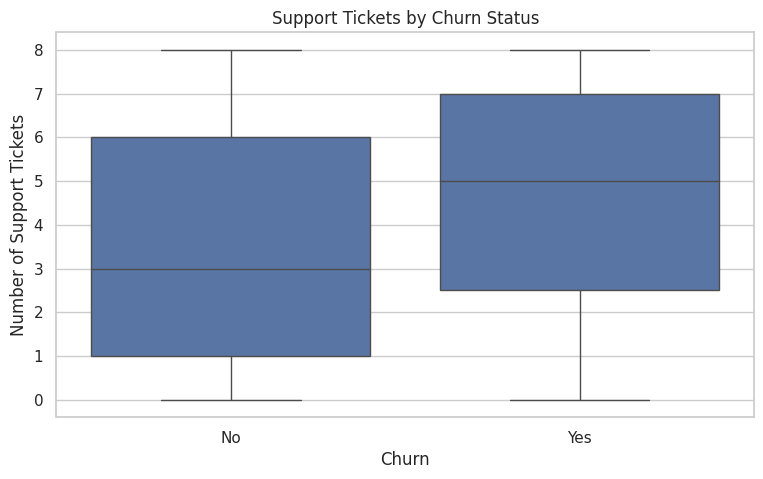

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="NumSupportTickets"
)

plt.title("Support Tickets by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Number of Support Tickets")

plt.show()

## 8.9 Internet Service and Churn Analysis

Customer churn is compared across different internet service categories to identify differences in churn behavior.

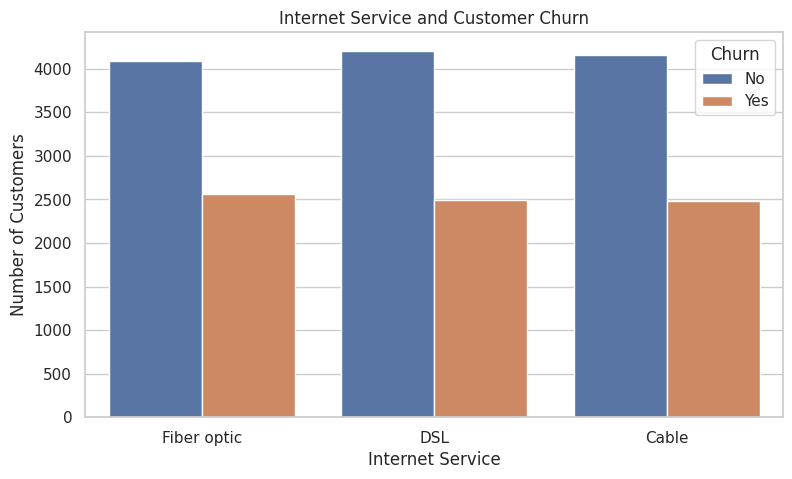

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service and Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

## 8.10 Payment Method and Churn Analysis

The distribution of customer churn across different payment methods is analyzed to identify potential differences between payment categories.

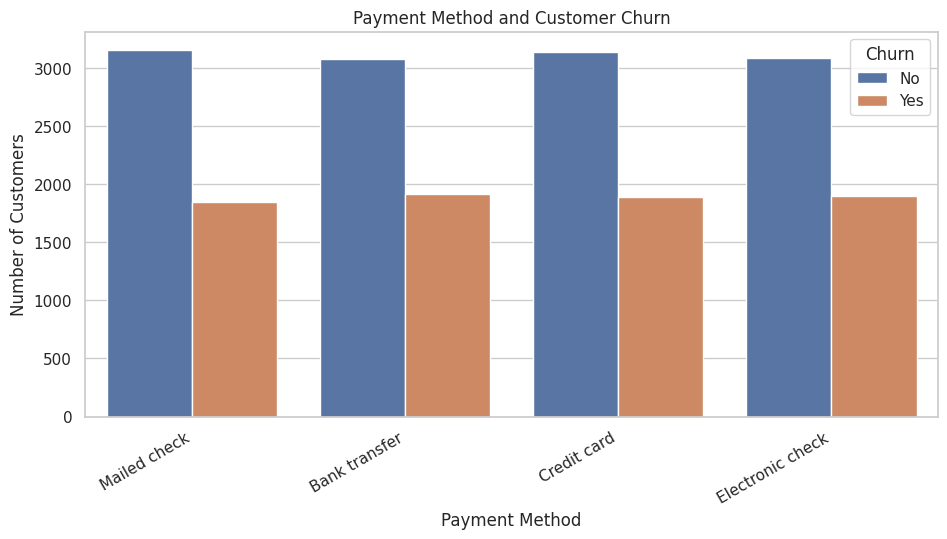

In [ ]:
plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method and Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")

plt.show()

## 8.11 Tenure and Monthly Charges Analysis

The relationship between customer tenure and monthly charges is analyzed while distinguishing customers according to their churn status.

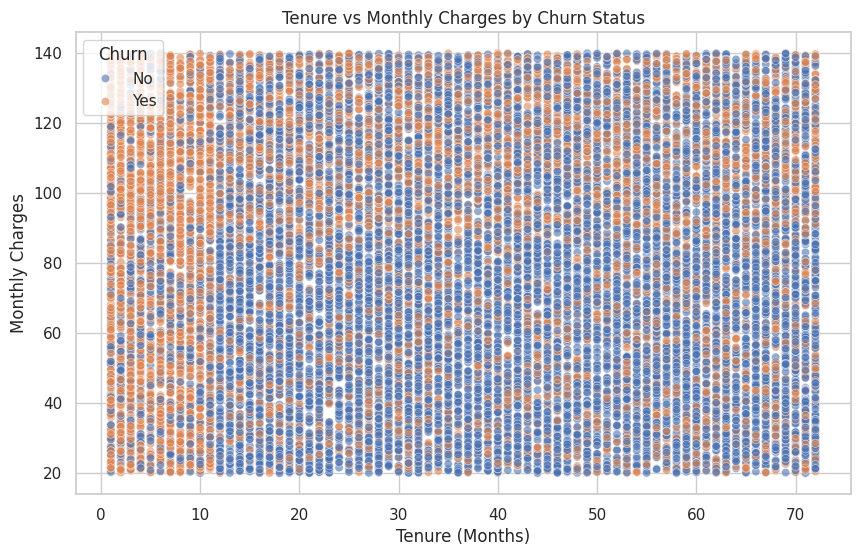

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="TenureMonths",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

## 8.12 Correlation Analysis

Correlation analysis is performed on numerical variables to identify relationships among customer-related attributes.

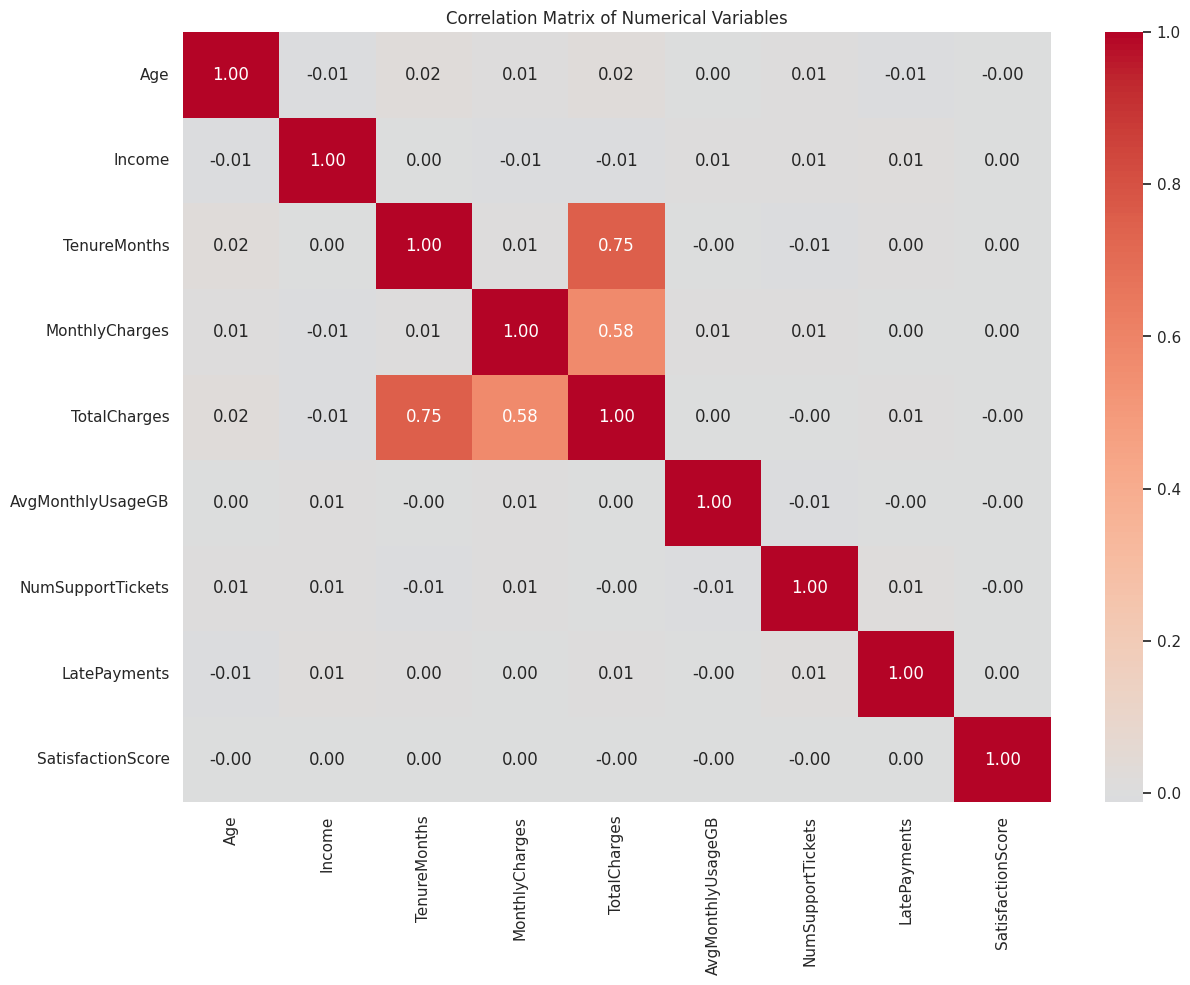

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

# 9. Machine Learning Preparation

After completing the exploratory data analysis, the dataset is prepared for the machine learning phase.

The objective of this phase is to prepare the customer data for classification models that can predict whether a customer is likely to churn.

The preparation process includes defining the input features and target variable, removing non-predictive identifiers, encoding the target variable, identifying numerical and categorical features, splitting the dataset into training and testing sets, and creating a preprocessing pipeline.

## 9.1 Define Features and Target

The `Churn` column is selected as the target variable because the main objective of the machine learning component is to predict customer churn.

All remaining columns are initially considered input features for the machine learning models.

In [ ]:
# Define input features and target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Variable Distribution:")
print(y.value_counts())

Features Shape: (20000, 30)
Target Shape: (20000,)

Target Variable Distribution:
Churn
No     12449
Yes     7551
Name: count, dtype: int64


## 9.2 Remove Customer Identifier

The `CustomerID` column is an identifier assigned to each customer. Since it does not represent a meaningful customer characteristic, it is removed from the input features before model training.

In [ ]:
# Remove CustomerID from the feature dataset

X = X.drop("CustomerID", axis=1)

print("CustomerID removed successfully.")
print("Updated Features Shape:", X.shape)

CustomerID removed successfully.
Updated Features Shape: (20000, 29)


## 9.3 Encode Target Variable

Machine learning classification algorithms require the target variable to be represented numerically. Therefore, the `Churn` values are converted into binary values.

`No` is represented by 0 and `Yes` is represented by 1.

In [ ]:
# Convert churn categories into binary values

y = y.map({
    "No": 0,
    "Yes": 1
})

print("Encoded Target Distribution:")
print(y.value_counts())

print("\nUnique Target Values:")
print(y.unique())

Encoded Target Distribution:
Churn
0    12449
1     7551
Name: count, dtype: int64

Unique Target Values:
[0 1]


## 9.4 Identify Numerical and Categorical Features

The input variables are divided into numerical and categorical features.

Numerical variables can be standardized, while categorical variables need to be converted into numerical form using encoding before they can be used by machine learning algorithms.

In [ ]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Numerical Features:
['Age', 'Income', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyUsageGB', 'NumSupportTickets', 'LatePayments', 'SatisfactionScore']

Categorical Features:
['Gender', 'SeniorCitizen', 'MaritalStatus', 'Dependents', 'Education', 'EmploymentStatus', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'CityTier', 'Referral']

Number of Numerical Features: 9
Number of Categorical Features: 20


## 9.5 Train-Test Split

The dataset is divided into training and testing sets.

The training dataset is used to train the machine learning models, while the testing dataset is used to evaluate their performance on previously unseen customer records.

A stratified split is used so that the distribution of churn classes remains approximately consistent in both datasets.

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Dataset Shape:", X_train.shape)
print("Testing Dataset Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training Dataset Shape: (16000, 29)
Testing Dataset Shape: (4000, 29)

Training Target Distribution:
Churn
0    0.622
1    0.378
Name: proportion, dtype: float64

Testing Target Distribution:
Churn
0    0.622
1    0.378
Name: proportion, dtype: float64


## 9.6 Create Data Preprocessing Pipeline

A preprocessing pipeline is created to prepare numerical and categorical variables automatically.

Numerical features are standardized using `StandardScaler`, while categorical features are converted into numerical representations using `OneHotEncoder`.

A `ColumnTransformer` is used to apply the appropriate transformation to each type of feature.

In [ ]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 9.7 Verify Preprocessing

The preprocessing pipeline is fitted on the training data and applied to both the training and testing datasets. This verifies that the feature transformation process is working correctly before model training.

In [ ]:
# Fit preprocessing on training data and transform both datasets

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original Training Shape:", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)

print("\nOriginal Testing Shape:", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)

print("\nPreprocessing completed successfully.")

Original Training Shape: (16000, 29)
Processed Training Shape: (16000, 56)

Original Testing Shape: (4000, 29)
Processed Testing Shape: (4000, 56)

Preprocessing completed successfully.


# 10. Machine Learning Model Development

In this section, machine learning classification models are developed to predict customer churn. Multiple models are trained and their performance is evaluated to identify how effectively customer churn can be predicted.

## 10.1 Logistic Regression

Logistic Regression is used as the first classification model for customer churn prediction. It estimates the probability of a customer belonging to the churn class based on the available customer features.

The model is trained using the preprocessing pipeline so that categorical variables are encoded and numerical variables are standardized before training.

In [ ]:
# ============================================================
# Logistic Regression Model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test)

# Generate churn probabilities
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_logistic[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_prob_logistic[:10].round(3))

Logistic Regression model trained successfully.

First 10 Predictions:
[1 1 1 1 1 0 0 0 1 0]

First 10 Churn Probabilities:
[0.95  0.733 0.984 0.762 0.507 0.246 0.219 0.142 0.647 0.034]


## 10.2 Decision Tree Classifier

The Decision Tree Classifier is used to identify relationships between customer characteristics and churn through a tree-based decision structure.

The model recursively divides the data using feature-based conditions to classify customers into churn and non-churn categories.

In [ ]:
# ============================================================
# Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Generate predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Generate churn probabilities
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_tree[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_prob_tree[:10].round(3))

Decision Tree model trained successfully.

First 10 Predictions:
[1 1 1 1 1 0 0 0 0 0]

First 10 Churn Probabilities:
[1.    1.    1.    1.    1.    0.082 0.057 0.067 0.079 0.065]


## 10.3 Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to produce a more robust classification model.

It is used to capture potentially complex relationships between customer characteristics and churn.

In [ ]:
# ============================================================
# Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = random_forest_model.predict(X_test)

# Generate churn probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_prob_rf[:10].round(3))

Random Forest model trained successfully.

First 10 Predictions:
[1 1 1 1 1 0 0 0 0 0]

First 10 Churn Probabilities:
[0.918 0.814 0.946 0.67  0.737 0.2   0.135 0.156 0.481 0.128]


## 10.4 Gradient Boosting Classifier

Gradient Boosting is an ensemble learning technique that builds a sequence of decision trees, where each subsequent tree attempts to improve the errors made by the previous trees.

It is included to capture more complex patterns in customer behavior and provide an additional model for comparison.

In [ ]:
# ============================================================
# Gradient Boosting Classifier
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting pipeline
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

# Generate predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Generate churn probabilities
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting model trained successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_gb[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_prob_gb[:10].round(3))

Gradient Boosting model trained successfully.

First 10 Predictions:
[1 1 1 1 1 0 0 0 0 0]

First 10 Churn Probabilities:
[0.978 0.878 0.986 0.841 0.909 0.106 0.016 0.133 0.36  0.046]


# 11. Model Evaluation

In this section, the performance of the developed machine learning models is evaluated using classification metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

## 11.1 Model Performance Comparison

The performance of Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting models is compared using multiple evaluation metrics. This provides a comprehensive view of the classification performance of each model.

In [ ]:
# ============================================================
# Model Performance Comparison
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Store models and predictions
model_results = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Gradient Boosting": (y_pred_gb, y_prob_gb)
}

# Calculate evaluation metrics
results = []

for model_name, (predictions, probabilities) in model_results.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

# Create comparison DataFrame
model_comparison = pd.DataFrame(results)

# Round values for clear presentation
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
] = model_comparison[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(4)

# Display results
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8285,0.7865,0.7490,0.7673,0.8837
1,Decision Tree,0.9540,0.9955,0.8821,0.9354,0.9410
2,Random Forest,0.9322,0.9725,0.8444,0.9039,0.9301
3,Gradient Boosting,0.9520,0.9889,0.8828,0.9328,0.9331


## 11.2 Confusion Matrix Analysis

A confusion matrix is used to evaluate the classification results of the machine learning models by comparing the actual customer churn status with the predicted churn status.

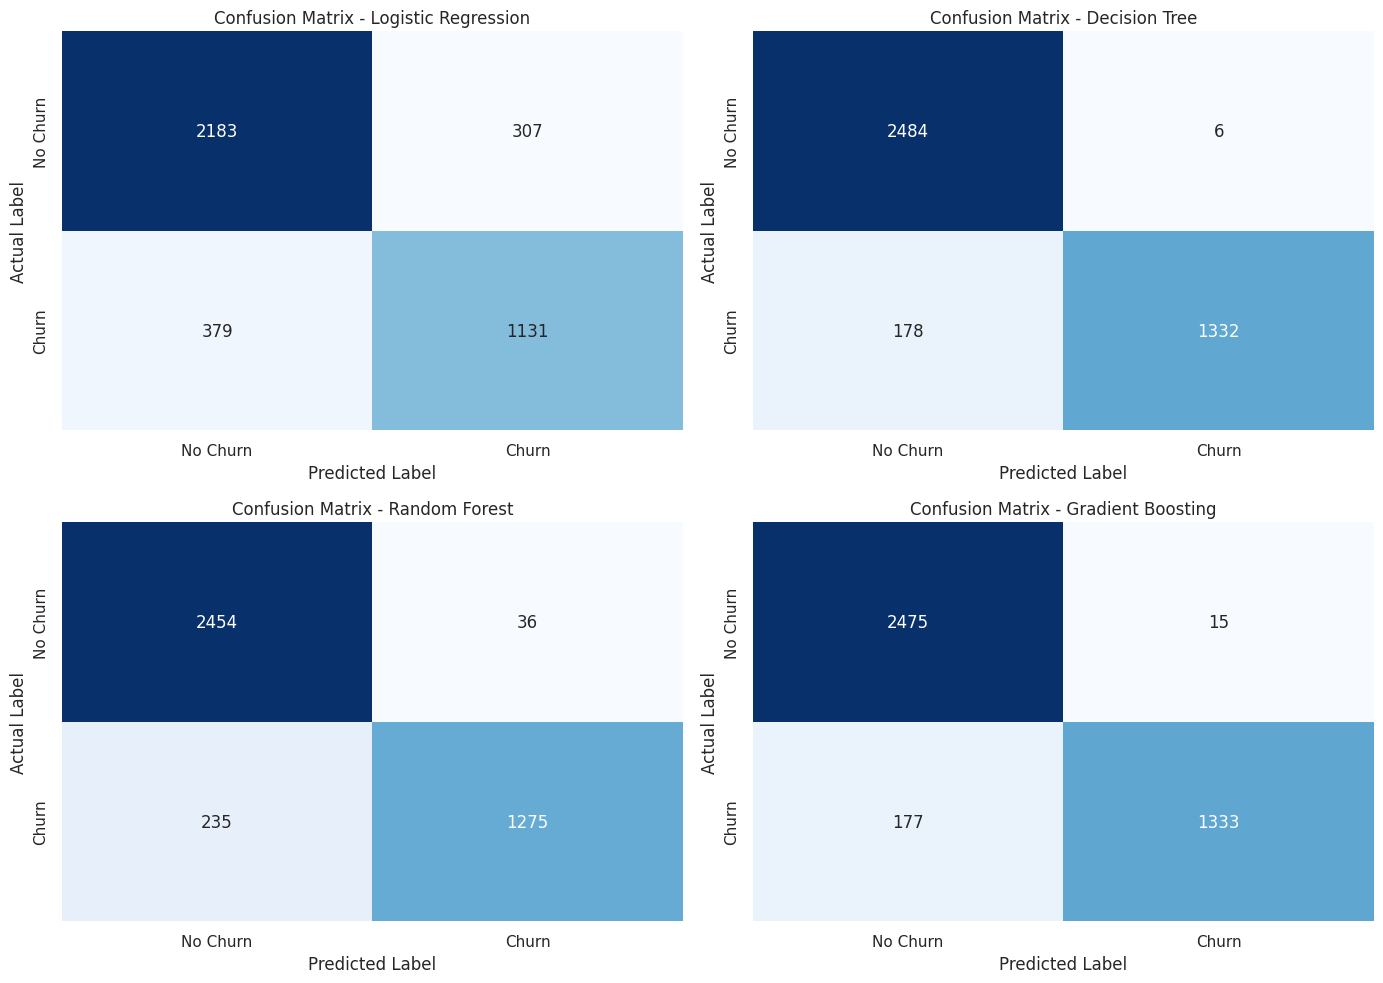

In [ ]:
# ============================================================
# Confusion Matrix Analysis
# ============================================================

from sklearn.metrics import confusion_matrix

# Store predictions for all models
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

# Create confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (model_name, predictions_model) in zip(
    axes.ravel(),
    predictions.items()
):
    cm = confusion_matrix(y_test, predictions_model)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"Confusion Matrix - {model_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_xticklabels(["No Churn", "Churn"])
    ax.set_yticklabels(["No Churn", "Churn"])

plt.tight_layout()
plt.show()

## 11.3 ROC-AUC Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the classification performance of the machine learning models at different probability thresholds. The Area Under the Curve (AUC) provides a measure of the model's ability to distinguish between churned and non-churned customers.

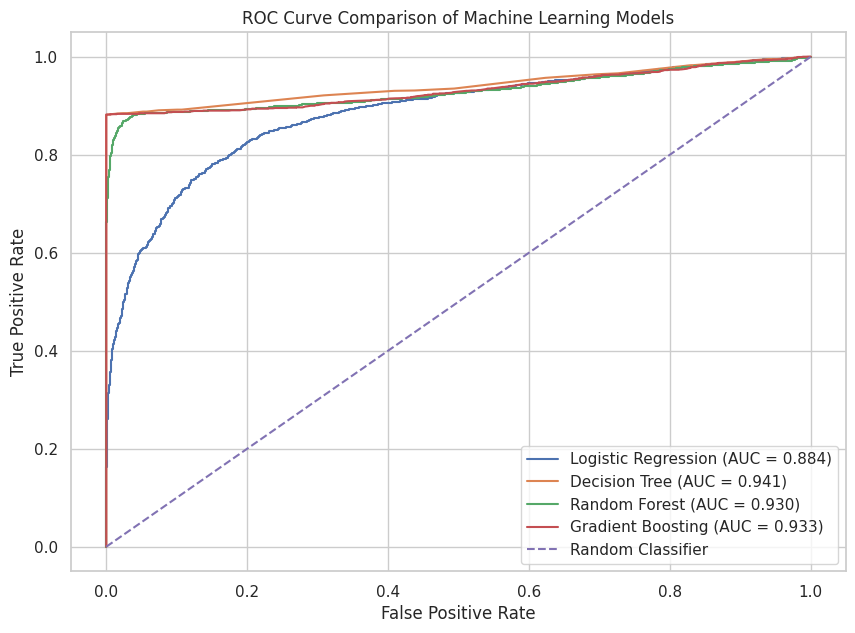

In [ ]:
# ============================================================
# ROC Curve and AUC Analysis
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Store probability predictions
probabilities = {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb
}

plt.figure(figsize=(10, 7))

for model_name, probabilities_model in probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities_model
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities_model
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison of Machine Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

## 11.4 Classification Report

The classification report provides detailed performance measures for each machine learning model, including precision, recall, F1-score, and support for both churn and non-churn classes.

In [ ]:
# ============================================================
# Classification Report for All Models
# ============================================================

from sklearn.metrics import classification_report

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for model_name, predictions_model in models_predictions.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions_model,
            target_names=["No Churn", "Churn"],
            digits=4,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn     0.8521    0.8767    0.8642      2490
       Churn     0.7865    0.7490    0.7673      1510

    accuracy                         0.8285      4000
   macro avg     0.8193    0.8129    0.8158      4000
weighted avg     0.8273    0.8285    0.8276      4000

Decision Tree
              precision    recall  f1-score   support

    No Churn     0.9331    0.9976    0.9643      2490
       Churn     0.9955    0.8821    0.9354      1510

    accuracy                         0.9540      4000
   macro avg     0.9643    0.9399    0.9498      4000
weighted avg     0.9567    0.9540    0.9534      4000

Random Forest
              precision    recall  f1-score   support

    No Churn     0.9126    0.9855    0.9477      2490
       Churn     0.9725    0.8444    0.9039      1510

    accuracy                         0.9323      4000
   macro avg     0.9426    0.9150    0.9258      4000
weighted avg     0.9352   

## 11.5 Precision-Recall Analysis

Precision-Recall analysis is used to examine the trade-off between correctly identifying churned customers and minimizing incorrect churn predictions.

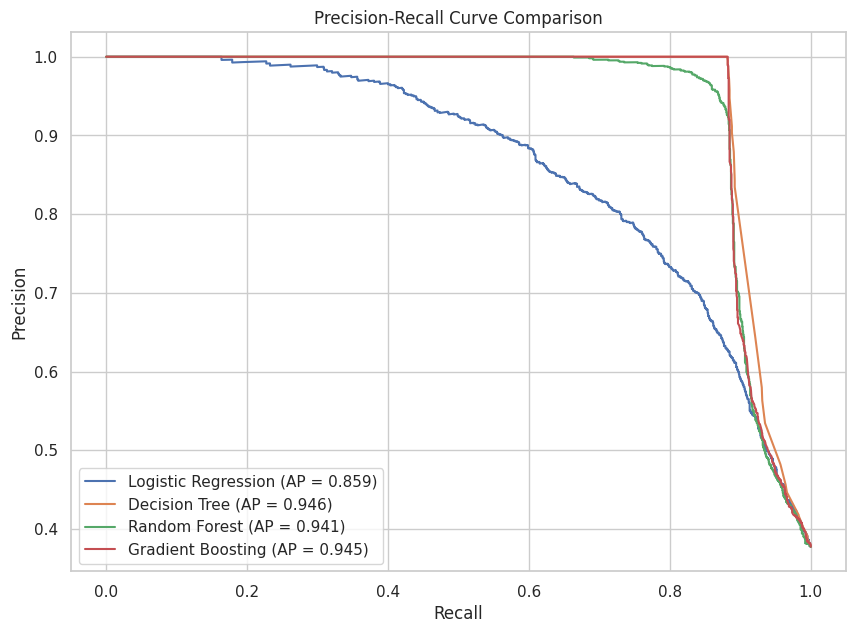

In [ ]:
# ============================================================
# Precision-Recall Curve Analysis
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for model_name, probabilities_model in probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities_model
    )

    ap_score = average_precision_score(
        y_test,
        probabilities_model
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {ap_score:.3f})"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.show()

# 12. Cross-Validation

Cross-validation is performed to evaluate the consistency of the machine learning models across multiple subsets of the training data. Stratified K-Fold cross-validation is used to maintain the class distribution in each fold.

## 12.1 Cross-Validation Model Comparison

The four machine learning models are evaluated using stratified 5-fold cross-validation. The mean and standard deviation of the ROC-AUC scores are calculated to examine model performance across different training and validation folds.

In [ ]:
# ============================================================
# 5-Fold Stratified Cross-Validation
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Store trained pipelines
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

# Create stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cross_validation_results = pd.DataFrame(cv_results)

cross_validation_results[
    ["Mean ROC-AUC", "Std ROC-AUC"]
] = cross_validation_results[
    ["Mean ROC-AUC", "Std ROC-AUC"]
].round(4)

display(cross_validation_results)

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.8791,0.0059
1,Decision Tree,0.9354,0.0060
2,Random Forest,0.9329,0.0054
3,Gradient Boosting,0.9347,0.0045


# 13. Hyperparameter Tuning

Hyperparameter tuning is performed to identify suitable model parameters that can improve machine learning performance. Grid Search with cross-validation is used to evaluate different parameter combinations.

## 13.1 Random Forest Hyperparameter Tuning

Grid Search is applied to the Random Forest classifier to evaluate different combinations of tree count, tree depth, and minimum sample requirements using cross-validation.

In [ ]:
# ============================================================
# Random Forest Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [8, 12],
    "classifier__min_samples_split": [5, 10],
    "classifier__min_samples_leaf": [2, 4]
}

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters:
{'classifier__max_depth': 12, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.9346


## 13.2 Tuned Random Forest Evaluation

The best Random Forest model identified through hyperparameter tuning is evaluated on the unseen test dataset to measure its generalization performance.

In [ ]:
# ============================================================
# Evaluate Tuned Random Forest
# ============================================================

best_rf_model = grid_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(X_test)
y_prob_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1]

tuned_rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned_rf),
    "Precision": precision_score(
        y_test,
        y_pred_tuned_rf,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_tuned_rf,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_tuned_rf,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_tuned_rf
    )
}

tuned_rf_results_df = pd.DataFrame(
    [tuned_rf_results],
    index=["Tuned Random Forest"]
).round(4)

display(tuned_rf_results_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Tuned Random Forest,0.9418,0.9768,0.8662,0.9182,0.9317


# 14. Final Model Comparison

The performance of the original machine learning models and the tuned Random Forest model is compared using multiple evaluation metrics. This comparison provides a consolidated view of the predictive performance obtained during the project.

## 14.1 Final Performance Table

The evaluation results of all developed models are combined into a single table for final analysis.

In [ ]:
# ============================================================
# Final Model Performance Comparison
# ============================================================

final_results = model_comparison.copy()

tuned_row = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [tuned_rf_results["Accuracy"]],
    "Precision": [tuned_rf_results["Precision"]],
    "Recall": [tuned_rf_results["Recall"]],
    "F1-Score": [tuned_rf_results["F1-Score"]],
    "ROC-AUC": [tuned_rf_results["ROC-AUC"]]
})

final_model_comparison = pd.concat(
    [final_results, tuned_row],
    ignore_index=True
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_model_comparison[metric_columns] = (
    final_model_comparison[metric_columns].round(4)
)

display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8285,0.7865,0.7490,0.7673,0.8837
1,Decision Tree,0.9540,0.9955,0.8821,0.9354,0.9410
2,Random Forest,0.9322,0.9725,0.8444,0.9039,0.9301
3,Gradient Boosting,0.9520,0.9889,0.8828,0.9328,0.9331
4,Tuned Random Forest,0.9418,0.9768,0.8662,0.9182,0.9317


# 15. Feature Importance

Feature importance is analyzed to understand which customer attributes contribute most to the predictions made by the tuned Random Forest model.

## 15.1 Random Forest Feature Importance

The importance values generated by the tuned Random Forest model are combined with the transformed feature names and visualized to identify the most influential features.

,Feature,Importance
8,SatisfactionScore,0.255602
42,Contract_Month-to-month,0.138028
2,TenureMonths,0.107317
3,MonthlyCharges,0.080882
4,TotalCharges,0.064521
6,NumSupportTickets,0.057991
7,LatePayments,0.053526
43,Contract_One year,0.049375
44,Contract_Two year,0.035771
1,Income,0.021676


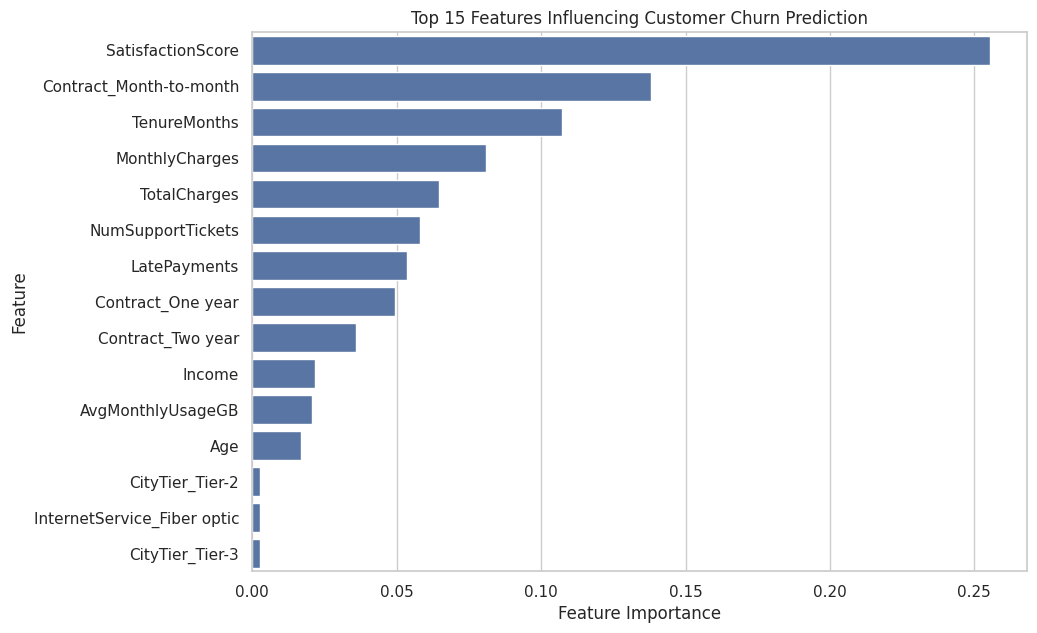

In [ ]:
# ============================================================
# Feature Importance Analysis
# ============================================================

# Get the preprocessing component
fitted_preprocessor = best_rf_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance values
importance_values = (
    best_rf_model
    .named_steps["classifier"]
    .feature_importances_
)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Clean feature names
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
top_features = feature_importance.head(15)

display(top_features)

# Plot top features
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

# 16. Customer Churn Prediction

The trained machine learning model is used to generate churn predictions and churn probabilities for customer records in the test dataset.

## 16.1 Generate Customer Churn Predictions

The tuned Random Forest model is used to predict the churn status and churn probability of customers from the test dataset.

In [ ]:
# ============================================================
# Customer Churn Prediction
# ============================================================

prediction_results = X_test.copy()

prediction_results["Actual_Churn"] = y_test.values

prediction_results["Predicted_Churn"] = y_pred_tuned_rf

prediction_results["Churn_Probability"] = (
    y_prob_tuned_rf.round(4)
)

prediction_results["Actual_Churn"] = (
    prediction_results["Actual_Churn"]
    .map({
        0: "No",
        1: "Yes"
    })
)

prediction_results["Predicted_Churn"] = (
    prediction_results["Predicted_Churn"]
    .map({
        0: "No",
        1: "Yes"
    })
)

display(prediction_results.head(10))

,Gender,Age,SeniorCitizen,MaritalStatus,Dependents,Education,EmploymentStatus,Income,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlyUsageGB,NumSupportTickets,LatePayments,SatisfactionScore,CityTier,Referral,Actual_Churn,Predicted_Churn,Churn_Probability
8482,Female,46,No,Married,Yes,Graduate,Self-Employed,147058,10,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,No,Mailed check,60.80,611.67,372.2,6,2,1,Tier-2,Yes,Yes,Yes,0.9511
15452,Male,56,No,Married,No,Graduate,Retired,88494,2,Yes,Yes,DSL,No,No,No,No,Yes,No,Month-to-month,No,Bank transfer,33.37,97.44,356.4,7,1,3,Tier-1,No,Yes,Yes,0.7429
15590,Male,19,No,Married,Yes,Post Graduate,Self-Employed,40512,7,Yes,Yes,Cable,Yes,No,No,No,No,Yes,Month-to-month,No,Electronic check,134.73,952.22,547.1,1,6,1,Tier-3,Yes,Yes,Yes,0.9543
17832,Male,30,No,Single,No,High School,Student,127348,23,Yes,Yes,Cable,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer,100.18,2268.05,108.7,2,2,2,Tier-3,Yes,Yes,Yes,0.7670
1079,Male,44,No,Married,No,High School,Retired,160359,8,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer,110.38,919.71,105.5,7,0,5,Tier-1,No,Yes,Yes,0.8029
6686,Male,56,No,Single,Yes,Graduate,Employed,131672,45,Yes,No,Cable,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,127.59,5714.38,535.2,0,2,4,Tier-1,Yes,No,No,0.1753
5834,Female,22,No,Married,Yes,Graduate,Retired,141142,30,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,60.70,1804.07,238.1,3,1,4,Tier-3,No,No,No,0.1292
18814,Female,49,No,Single,No,High School,Employed,110664,50,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,One year,Yes,Mailed check,87.55,4338.21,272.6,0,6,2,Tier-2,Yes,No,No,0.1172
2829,Female,53,No,Married,Yes,High School,Self-Employed,170034,33,Yes,Yes,Cable,No,No,No,Yes,No,Yes,Month-to-month,No,Credit card,78.80,2603.22,117.1,3,1,2,Tier-1,Yes,No,No,0.4088
7518,Male,71,Yes,Married,No,Post Graduate,Retired,54242,55,Yes,No,DSL,Yes,No,No,Yes,Yes,Yes,One year,Yes,Credit card,120.94,6637.89,543.7,5,1,4,Tier-1,No,No,No,0.0918


# 17. Final Model Confusion Matrix

The confusion matrix of the tuned Random Forest model is visualized to examine the number of correctly and incorrectly classified churn and non-churn customers.

## 17.1 Tuned Random Forest Confusion Matrix

The confusion matrix summarizes the final model's classification results by comparing actual customer churn status with predicted churn status.

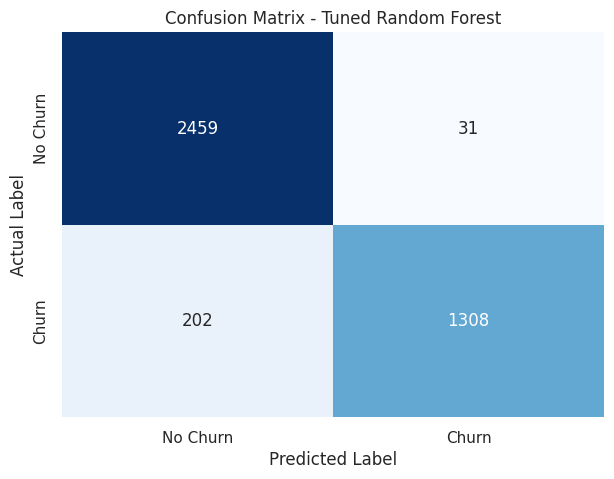

In [ ]:
# ============================================================
# Final Confusion Matrix
# ============================================================

final_cm = confusion_matrix(
    y_test,
    y_pred_tuned_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# 18. Final ROC Curve

The ROC curve of the tuned Random Forest model is presented to evaluate its ability to distinguish between customers who churn and customers who do not churn.

## 18.1 Tuned Random Forest ROC Curve

The ROC curve and corresponding AUC value are generated for the final tuned model.

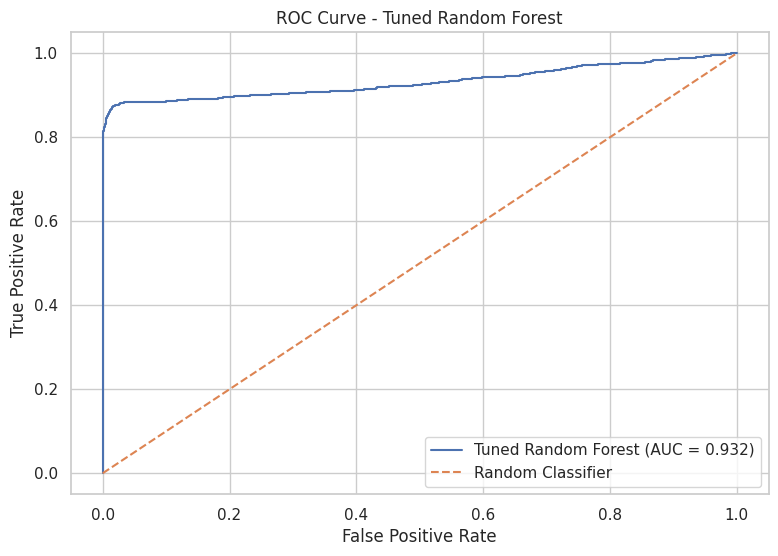

Final ROC-AUC Score: 0.9317


In [ ]:
# ============================================================
# Final ROC Curve
# ============================================================

fpr_final, tpr_final, _ = roc_curve(
    y_test,
    y_prob_tuned_rf
)

final_auc = roc_auc_score(
    y_test,
    y_prob_tuned_rf
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_final,
    tpr_final,
    label=f"Tuned Random Forest (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

print("Final ROC-AUC Score:", round(final_auc, 4))

# 19. Final Classification Report

The final classification report provides detailed precision, recall, F1-score, and support values for the tuned Random Forest model.

In [ ]:
# ============================================================
# Final Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_tuned_rf,
        target_names=["No Churn", "Churn"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn     0.9241    0.9876    0.9548      2490
       Churn     0.9768    0.8662    0.9182      1510

    accuracy                         0.9417      4000
   macro avg     0.9505    0.9269    0.9365      4000
weighted avg     0.9440    0.9417    0.9410      4000



# 20. Final Project Findings

The final findings summarize the major observations obtained from exploratory data analysis and the machine learning experiments. The findings are based on the actual results generated from the customer churn dataset.

In [ ]:
# ============================================================
# Final Project Summary
# ============================================================

best_model_row = final_model_comparison.loc[
    final_model_comparison["ROC-AUC"].idxmax()
]

print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"\nTotal Customers Analyzed: {len(df):,}")

print(
    f"Churned Customers: "
    f"{(df['Churn'] == 'Yes').sum():,}"
)

print(
    f"Overall Churn Rate: "
    f"{(df['Churn'] == 'Yes').mean() * 100:.2f}%"
)

print(
    f"\nHighest ROC-AUC in Model Comparison: "
    f"{best_model_row['Model']}"
)

print(
    f"ROC-AUC: "
    f"{best_model_row['ROC-AUC']:.4f}"
)

print("\nFinal Tuned Random Forest Metrics:")
print(
    f"Accuracy:  {tuned_rf_results['Accuracy']:.4f}"
)
print(
    f"Precision: {tuned_rf_results['Precision']:.4f}"
)
print(
    f"Recall:    {tuned_rf_results['Recall']:.4f}"
)
print(
    f"F1-Score:  {tuned_rf_results['F1-Score']:.4f}"
)
print(
    f"ROC-AUC:   {tuned_rf_results['ROC-AUC']:.4f}"
)

FINAL PROJECT SUMMARY

Total Customers Analyzed: 20,000
Churned Customers: 7,551
Overall Churn Rate: 37.76%

Highest ROC-AUC in Model Comparison: Decision Tree
ROC-AUC: 0.9410

Final Tuned Random Forest Metrics:
Accuracy:  0.9417
Precision: 0.9768
Recall:    0.8662
F1-Score:  0.9182
ROC-AUC:   0.9317


# 21. Conclusion

- This project combined data analytics and machine learning to analyze and predict customer churn.

- The analytical phase examined customer demographics, services, contracts, billing information, tenure, satisfaction, support activity, and relationships among numerical variables.

- The machine learning phase involved data preprocessing, feature transformation, multiple classification algorithms, cross-validation, hyperparameter tuning, and model evaluation using several performance metrics.

- The developed models provide a data-driven approach for understanding customer churn patterns and predicting potential churn based on customer characteristics.

- The results and visualizations generated throughout the project will be used to prepare the final project report.